In [ ]:
df = pd.read_csv('./xAPI-Edu-Data.csv')

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df['Class_value'] = df['Class'].map(dict(L=-1, M=0, H=1))
df.head()

,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class,Class_value
0,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,15,16,2,20,Yes,Good,Under-7,M,0
1,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,20,20,3,25,Yes,Good,Under-7,M,0
2,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,10,7,0,30,No,Bad,Above-7,L,-1
3,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,30,25,5,35,No,Bad,Above-7,L,-1
4,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,40,50,12,50,No,Bad,Above-7,M,0


In [ ]:
df.groupby('gender').mean(numeric_only=True)

,raisedhands,VisITedResources,AnnouncementsView,Discussion,Class_value
gender,,,,,
F,52.862857,64.000000,39.748571,47.828571,0.291429
M,43.281967,49.518033,36.868852,40.675410,-0.118033


In [ ]:
df['Class'] = df['Class'].map(dict(H=0, L=1, M=2))

In [ ]:
X = pd.get_dummies(df.drop(['ParentschoolSatisfaction', 'PlaceofBirth', 'Class'],axis=1),
                   columns = ['gender', 'NationalITy',
                              'StageID', 'GradeID', 'SectionID', 'Topic',
                              'Semester', 'Relation', 'ParentAnsweringSurvey',
                              'StudentAbsenceDays'],
                   drop_first =True).astype('int')
y=df['Class']

In [ ]:
X.head()

,raisedhands,VisITedResources,AnnouncementsView,Discussion,Class_value,gender_M,NationalITy_Iran,NationalITy_Iraq,NationalITy_Jordan,NationalITy_KW,...,Topic_History,Topic_IT,Topic_Math,Topic_Quran,Topic_Science,Topic_Spanish,Semester_S,Relation_Mum,ParentAnsweringSurvey_Yes,StudentAbsenceDays_Under-7
0,15,16,2,20,0,1,0,0,0,1,...,0,1,0,0,0,0,0,0,1,1
1,20,20,3,25,0,1,0,0,0,1,...,0,1,0,0,0,0,0,0,1,1
2,10,7,0,30,-1,1,0,0,0,1,...,0,1,0,0,0,0,0,0,0,0
3,30,25,5,35,-1,1,0,0,0,1,...,0,1,0,0,0,0,0,0,0,0
4,40,50,12,50,0,1,0,0,0,1,...,0,1,0,0,0,0,0,0,0,0


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scakedX = scaler.fit_transform(X)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(scakedX, y, test_size=0.3, random_state=1)

In [ ]:
import numpy as np
# 데이터 분리
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.3, random_state=1)

In [ ]:
print(f'train : {X_train.shape}, {y_train.shape}')
print(f'val : {X_val.shape}, {y_val.shape}')
print(f'test : {X_test.shape}, {y_test.shape}')

train : (235, 47), (235,)
val : (101, 47), (101,)
test : (144, 47), (144,)


In [ ]:
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train)
y_val = to_categorical(y_val)
y_test = to_categorical(y_test)

In [ ]:
X.shape

(480, 47)

In [ ]:
from tensorflow.keras.layers import Dense, Flatten, Input
from tensorflow.keras.models import Sequential

model = Sequential()

model.add(Input(shape=(47,)))
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(3, activation='softmax'))

In [ ]:
model.compile(optimizer = 'adam',
              loss = 'categorical_crossentropy',
              metrics = ['acc'])

In [ ]:
history = model.fit(X_train, y_train,
                    epochs=300,
                    batch_size=128,
                    validation_data=(X_val, y_val))

Epoch 1/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 236ms/step - acc: 0.4317 - loss: 1.1317 - val_acc: 0.4950 - val_loss: 1.0112
Epoch 2/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - acc: 0.4087 - loss: 1.0989 - val_acc: 0.5248 - val_loss: 0.9868
Epoch 3/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - acc: 0.4598 - loss: 1.0203 - val_acc: 0.5050 - val_loss: 0.9647
Epoch 4/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - acc: 0.4740 - loss: 0.9817 - val_acc: 0.5050 - val_loss: 0.9449
Epoch 5/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - acc: 0.5315 - loss: 0.9401 - val_acc: 0.5149 - val_loss: 0.9268
Epoch 6/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - acc: 0.5603 - loss: 0.9043 - val_acc: 0.5248 - val_loss: 0.9095
Epoch 7/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - acc: 0.6284 - loss: 0.8743 - val_acc: 0.5545 - val_loss: 0.8922
Epoch 8/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - acc: 0.6641 - loss: 0.8499 - val_acc: 0.5842 - val_loss: 0.8756
Epoch 9/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - acc: 0.6970 - loss:

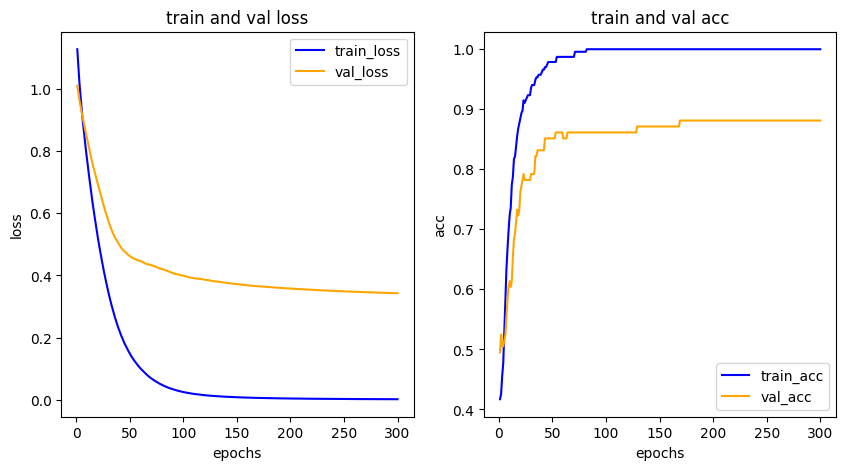

In [ ]:
his_dict = history.history
loss = his_dict['loss']
val_loss = his_dict['val_loss']

epochs = range(1, len(loss) + 1)
fig = plt.figure(figsize=(10, 5))

# 훈련 및 검증 손실 그리기
ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(epochs, loss, color = 'blue', label='train_loss')
ax1.plot(epochs, val_loss, color = 'orange', label='val_loss')
ax1.set_title('train and val loss')
ax1.set_xlabel('epochs')
ax1.set_ylabel('loss')
ax1.legend()

acc = his_dict['acc']
val_acc = his_dict['val_acc']

ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(epochs, acc, color = 'blue', label='train_acc')
ax2.plot(epochs, val_acc, color = 'orange', label='val_acc')
ax2.set_title('train and val acc')
ax2.set_xlabel('epochs')
ax2.set_ylabel('acc')
ax2.legend()

plt.show()

In [ ]:
model.evaluate(X_test, y_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9188 - loss: 0.2639 


[0.33334481716156006, 0.8958333134651184]

In [ ]:
results = model.predict(X_test)
print(results.shape)
np.set_printoptions(precision=7)
print(f'각 클래스에 속할 확률 : \n{results [0]}')

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
(144, 3)
각 클래스에 속할 확률 : 
[9.9476928e-01 1.2355562e-09 5.2307020e-03]


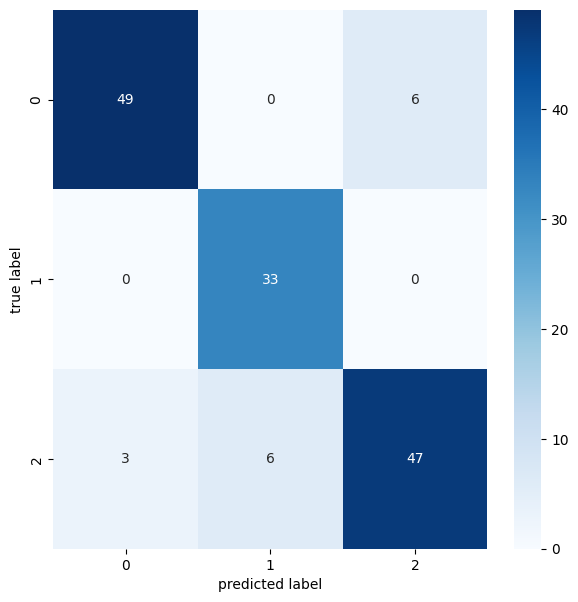

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 7))
cm = confusion_matrix(np.argmax(y_test, axis = 1), np.argmax(results, axis = -1))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('predicted label')
plt.ylabel('true label')
plt.show()

In [ ]:
print('\n', classification_report(np.argmax(y_test, axis = 1), np.argmax(results, axis = -1)))


               precision    recall  f1-score   support

           0       0.94      0.89      0.92        55
           1       0.85      1.00      0.92        33
           2       0.89      0.84      0.86        56

    accuracy                           0.90       144
   macro avg       0.89      0.91      0.90       144
weighted avg       0.90      0.90      0.90       144

